# Low-Rank Structure in Gaussian Covariances

This notebook explores how low-rank changes in Gaussian coefficient matrices affect covariance structure.
The emphasis is on empirical covariance, eigenvalues, and matrix rank.

## Background

$$
x = W z + \varepsilon,\quad z \sim \mathcal{N}(0, I_k),\quad \varepsilon \sim \mathcal{N}(0, \sigma^2 I_d)
$$

$$
\Sigma = W W^\top + \sigma^2 I_d.
$$

In [695]:
import matplotlib.pyplot as plt
import numpy as np


rng = np.random.default_rng(0)

In [696]:
d = 50
k = 8
sigma = 1
n = 500000
rank_star = 1


In [697]:
W0 = rng.normal(size=(d, k))
Sigma0 = W0 @ W0.T + sigma**2 * np.eye(d)

## Low-Rank vs Diffuse Coefficient Changes

In [698]:
def sample(W):
    z = rng.normal(size=(n, k))
    eps = sigma * rng.normal(size=(n, d))
    return z @ W.T + eps

In [699]:
B = rng.normal(size=(d, rank_star))
A = rng.normal(size=(rank_star, k))
DeltaW_lr = B @ A

W_lr = W0 + DeltaW_lr
X_lr = sample(W_lr)
S_lr = (X_lr.T @ X_lr) / n


In [700]:
# Compute Frobenius norm
fro_low = np.linalg.norm(DeltaW_lr, 'fro')

# Compute Frobenius norm before scaling
DeltaW_dense = rng.normal(size=(d, k))
fro_diffuse = np.linalg.norm(DeltaW_dense, 'fro')

# Scale diffuse matrix to match Frobenius norm
DeltaW_dense *= fro_low / fro_diffuse

# Verify equality
fro_diffuse_scaled = np.linalg.norm(DeltaW_dense, 'fro')

print("Frobenius norm (low-rank): ", fro_low)
print("Frobenius norm (diffuse):  ", fro_diffuse_scaled)

W_dense = W0 + DeltaW_dense
X_dense = sample(W_dense)
S_dense = (X_dense.T @ X_dense) / n


Frobenius norm (low-rank):  15.3686790357706
Frobenius norm (diffuse):   15.3686790357706


In [701]:
def sorted_eigenvalues(A):
    # Eigenvalues of a symmetric matrix
    eigvals = np.linalg.eigvalsh(A)   # ascending order
    return eigvals[::-1] # reverse to get descending order

In [702]:
# Compute and sort eigenvalues
eig0 = sorted_eigenvalues(Sigma0)
eig_lr = sorted_eigenvalues(S_lr)
eig_dense = sorted_eigenvalues(S_dense)

In [703]:
assert np.allclose(Sigma0, Sigma0.T)
assert np.allclose(S_lr, S_lr.T)
assert np.allclose(S_dense, S_dense.T)

# Positive semidefinite check
assert np.all(eig0 >= -1e-10)
assert np.all(eig_lr >= -1e-10)
assert np.all(eig_dense >= -1e-10)

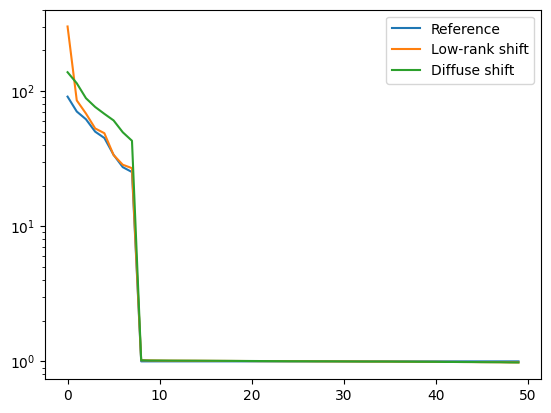

In [704]:
# Plot eigenvalues
plt.semilogy(eig0, label='Reference')
plt.semilogy(eig_lr, label='Low-rank shift')
plt.semilogy(eig_dense, label='Diffuse shift')
plt.legend()
plt.show()

Step 3: Quantify “significant change”

In [705]:
threshold = 0.10  # 10% relative difference

def count_significant_changes(eig_ref, eig_test, threshold=0.10):
    rel_diff = np.abs(eig_test - eig_ref) / eig_ref
    return np.sum(rel_diff > threshold)

In [706]:
num_changed_lowrank = count_significant_changes(
    eig0, eig_lr, threshold
)

num_changed_diffuse = count_significant_changes(
    eig0, eig_dense, threshold
)

num_changed_lowrank, num_changed_diffuse

(np.int64(3), np.int64(8))


Step 4: Interpret the results

1. In the low-rank case, how many eigenvalues change substantially, and how does this number relate to the rank of the coefficient modification?

In finite samples (1500 earlier), the number of eigenvalues change substantially that exceeds rank_star due to spectral leakage—low-rank perturbations propagate beyond their exact low-rank subspace in empirical estimates. However, compared to the diffuse case with the same Frobenius norm, the low-rank perturbation affects fewer directions, demonstrating the concentrating effect of low-rank structure on variance changes. Increasing the number of samples helps in reducing the eigenvalues change.


2. In the diffuse case, why are many eigenvalues affected, even though the overall magnitude of the change is the same?
In the diffuse case, many eigenvalues are affected even though the overall magnitude of the change is the same. This is because in diffuse modification, the signal energy is spread across many directions though it is weak. 

3. How do these observations illustrate the idea that matrix rank limits the number of variance directions that can change?
The matrix rank limits how many variance directions can change. A low rank modification concentrates variance into a small space and therefore alters only a few eigenvalues whereas diffusion modification distributes the variance across many directions causing many eigenvalues to change.